SECP3223-02 DATA ANALYTICS PROGRAMMING

GROUP PROJECT PHASE 1

Group member name:
1. Dayang Farah Farzana binti Abang Idham A23CS0071
2. Farra Nurzahin binti Zaharil Anuar A23CS0079
3. Safiya Nursyahadah binti Masnoor A23CS0176

In [4]:
#We use pandas to load two datasets

import pandas as pd

fuel_df = pd.read_csv(r"C:/ProjectDAP/FuelConsumption.csv")
cars_df = pd.read_csv(r"C:/ProjectDAP/cars_2025.csv")
fuel_df
cars_df

,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,BYD,Seal,white,electric,Rakan Niaga
1,2025-01-01,window_van,Cam,Placer-X,yellow,greendiesel,Johor
2,2025-01-01,jip,Chery,Jaecoo J7,green,petrol,Rakan Niaga
3,2025-01-01,jip,Chery,Jaecoo J7,silver,petrol,Rakan Niaga
4,2025-01-01,jip,Chery,Tiggo,grey,petrol,Rakan Niaga
...,...,...,...,...,...,...,...
263573,2025-04-30,window_van,Zeekr,009,black,electric,W.P. Kuala Lumpur
263574,2025-04-30,window_van,Zeekr,009,black,electric,W.P. Kuala Lumpur
263575,2025-04-30,window_van,Zeekr,009,black,electric,W.P. Kuala Lumpur
263576,2025-04-30,window_van,Zeekr,009,black,electric,Rakan Niaga


In [5]:
#We examine the structure of the data using;
# 1. (.shape) - shows the number of rows and columns
# 2. (.dtypes) - shows the data tyopes pf each column
# 3. (head()) - displays the first 5 rows of each dataset

print(fuel_df.shape)
print(fuel_df.dtypes)
print(fuel_df.head())

print(cars_df.shape)
print(cars_df.dtypes)
print(cars_df.head())


(1067, 13)
MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object
   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0         

In [6]:
# Print the column names

print(cars_df.columns)
print(fuel_df.columns)

Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')
Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')


In [7]:
#Rename the maker and model columns in the cars_df Dataframe to MAKE and MODEL so that 
#they match the column in fuel_df
cars_df.rename(columns={'maker': 'MAKE', 'model': 'MODEL'}, inplace=True)

# Then clean the new columns:
cars_df['MAKE'] = cars_df['MAKE'].fillna('').str.strip().str.upper()
cars_df['MODEL'] = cars_df['MODEL'].fillna('').str.strip().str.upper()


In [8]:
#Merge both datasets

merged_df = pd.merge(cars_df, fuel_df, how='left', on=['MAKE', 'MODEL'])


In [9]:
#Find and counts all rows in data where the CO2EMISSIONS value is missing

unmatched = merged_df[merged_df['CO2EMISSIONS'].isnull()]
print(f"Unmatched rows: {unmatched.shape[0]}")


Unmatched rows: 251480


In [10]:
#Saves merged data into a CSV file ("Merged_Dataset_Phase1.csv")

merged_df.to_csv("Merged_Dataset_Phase1.csv", index=False)


In [11]:
#Extracts all rows where CO2EMISSIONS is availablle and saves them to a CSV file

matched_df = merged_df[merged_df['CO2EMISSIONS'].notnull()]
matched_df.to_csv("Matched_Dataset_Phase1.csv", index=False)


### 🔍 Matching Summary

- Total car registrations (2025): 263,578
- Total emission records (2014): 1,067
- Total matched rows after merging: ~12,098
- Unmatched rows: 251,480

#### 📌 Observations:
- Many newer or local car models in Malaysia (2025) are not present in the 2014 dataset.
- This leads to a high number of unmatched rows.
- Matching was done using standardized `MAKE` and `MODEL` fields.


In [21]:
#Load the merged dataset
merged_df = pd.read_csv(r"C:/ProjectDAP/Merged_Dataset_Phase1.csv")

#Display the first few rows to review the data
merged_df.head()

,date_reg,type,MAKE,MODEL,colour,fuel,state,MODELYEAR,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2025-01-01,motokar,BYD,SEAL,white,electric,Rakan Niaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,window_van,CAM,PLACER-X,yellow,greendiesel,Johor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,jip,CHERY,JAECOO J7,green,petrol,Rakan Niaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,jip,CHERY,JAECOO J7,silver,petrol,Rakan Niaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,jip,CHERY,TIGGO,grey,petrol,Rakan Niaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
#Display number of rows before data cleaning
merged_df.shape[0]

277343

In [133]:
#We perform data cleaning and preparation by doing:

#1. Check each column's dtype
for col in merged_df.columns:
    print(col, merged_df[col].dtype)

date_reg object
type object
MAKE object
MODEL object
colour object
fuel object
state object
MODELYEAR float64
VEHICLECLASS object
ENGINESIZE float64
CYLINDERS float64
TRANSMISSION object
FUELTYPE object
FUELCONSUMPTION_CITY float64
FUELCONSUMPTION_HWY float64
FUELCONSUMPTION_COMB float64
FUELCONSUMPTION_COMB_MPG float64
CO2EMISSIONS float64


In [27]:
#2. Classify the same dtype into lists to standardize the text and formats of the file
# We want to have 'MAKE' and 'MODEL' stay in uppercase hence the makemodel_columns 
text_columns = ["date_reg", "type", "colour", "fuel", "state", "VEHICLECLASS",
                "TRANSMISSION", "FUELTYPE"]
numeric_columns = ["MODELYEAR", "ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB", 
                   "FUELCONSUMPTION_COMB_MPG", "CO2EMISSIONS"]
makemodel_columns = ["MAKE", "MODEL"]

#3. Fill missing values with 0 or NaN
merged_df[numeric_columns] = merged_df[numeric_columns].fillna(0)

merged_df[text_columns] = merged_df[text_columns].fillna('NA')
merged_df[makemodel_columns] = merged_df[makemodel_columns].fillna('NA')

#4. Remove duplicates rows
merged_df = merged_df.drop_duplicates()
merged_df.shape[0]

53240

In [33]:
#5. Perform:
# str.strip() - remove extra spaces
# Convert all text_columns value to string
# replace word nan to NaN after string cleaning
for col in text_columns:
    merged_df[col] = merged_df[col].astype(str).str.strip()

#6. Convert all numeric_columns value to float
for col in numeric_columns:
    merged_df[col] = merged_df[col].astype(float)

In [31]:
#Show info to check datatypes and non-null counts
merged_df.info()

#View the cleaned data
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 53240 entries, 0 to 277341
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date_reg                  53240 non-null  object 
 1   type                      53240 non-null  object 
 2   MAKE                      53240 non-null  object 
 3   MODEL                     53240 non-null  object 
 4   colour                    53240 non-null  object 
 5   fuel                      53240 non-null  object 
 6   state                     53240 non-null  object 
 7   MODELYEAR                 53240 non-null  float64
 8   VEHICLECLASS              53240 non-null  object 
 9   ENGINESIZE                53240 non-null  float64
 10  CYLINDERS                 53240 non-null  float64
 11  TRANSMISSION              53240 non-null  object 
 12  FUELTYPE                  53240 non-null  object 
 13  FUELCONSUMPTION_CITY      53240 non-null  float64
 14  FUELCONSUM

,date_reg,type,MAKE,MODEL,colour,fuel,state,MODELYEAR,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2025-01-01,motokar,BYD,SEAL,white,electric,Rakan Niaga,0.0,NA,0.0,0.0,NA,NA,0.0,0.0,0.0,0.0,0.0
1,2025-01-01,window_van,CAM,PLACER-X,yellow,greendiesel,Johor,0.0,NA,0.0,0.0,NA,NA,0.0,0.0,0.0,0.0,0.0
2,2025-01-01,jip,CHERY,JAECOO J7,green,petrol,Rakan Niaga,0.0,NA,0.0,0.0,NA,NA,0.0,0.0,0.0,0.0,0.0
3,2025-01-01,jip,CHERY,JAECOO J7,silver,petrol,Rakan Niaga,0.0,NA,0.0,0.0,NA,NA,0.0,0.0,0.0,0.0,0.0
4,2025-01-01,jip,CHERY,TIGGO,grey,petrol,Rakan Niaga,0.0,NA,0.0,0.0,NA,NA,0.0,0.0,0.0,0.0,0.0


In [105]:
#Saved the update dataset to a new CSV file
merged_df.to_csv('Cleaned_Merged_Dataset_Phase1.csv', index=False);

### 🔍 Data Cleaning, Preparation and Wrangling Summary

- Total original rows: 277,343
- Total rows after cleaning: 53240
- Total columns: 18 
- Numeric columns cleaned: 8
- Text columns cleaned: 7
- `MAKE` and `MODEL` columns cleaned separately

#### 📌 Observations:
- All missing numeric values filled with 0 while missing text values replaced with 'NA'
- Text values were standardized by stripped extra spaces and converted to string type
- Duplicate rows were removed

In [107]:
# Group the data by MAKE and MODEL
agg_df = (
    fuel_df.groupby(['MAKE', 'MODEL'])
    .agg(
        count=('MODEL', 'count'),  # Count of records
        avg_fuel_consumption=('FUELCONSUMPTION_COMB', 'mean'),  # Average combined fuel use
        avg_co2_emission=('CO2EMISSIONS', 'mean')  # Average CO2 emission
    )
    .reset_index()
    .sort_values(by='count', ascending=False) 
)

# Display the aggregated DataFrame
print(agg_df.head())

# Save the final dataset to CSV for Phase II
agg_df.to_csv("aggregated_fuel_data.csv", index=False)

           MAKE         MODEL  count  avg_fuel_consumption  avg_co2_emission
229        FORD      F150 FFV      8             15.775000        299.500000
230        FORD  F150 FFV 4X4      8             16.550000        314.125000
274       HONDA        ACCORD      6              9.050000        208.166667
239        FORD     FOCUS FFV      6              9.116667        173.333333
636  VOLKSWAGEN        BEETLE      6              9.183333        211.166667


📌 Aggregation & Final Dataset Preparation
This section focuses on aggregating key metrics from the FuelConsumption.csv dataset to prepare a summarized dataset for further analysis in Phase II.

Steps performed : 

- Data was grouped by MAKE and MODEL to consolidate vehicle entries.
- Three main aggregations were performed for each group :
  1. count : Number of cars for each MAKE-MODEL combination.
  2. avg_fuel_consumption : Average combined fuel consumption.
  3. avg_co2_emission : Average CO2 emission.

The grouped data was sorted by the number of records to highlight the most common car models.

The final cleaned and aggregated dataset was saved as aggregated_fuel_data.csv for use in next phase.

In [154]:
import pandas as pd

df=matched_df.copy()

# 1. Quick data check
print("=== Dataset Info ===")
df.info()                       # column types & non-null counts
print("\n=== Missing Values ===")
print(df.isna().sum())          # count of NaNs per column

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 25863 entries, 57 to 277315
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date_reg                  25863 non-null  object 
 1   type                      25863 non-null  object 
 2   MAKE                      25863 non-null  object 
 3   MODEL                     25863 non-null  object 
 4   colour                    25863 non-null  object 
 5   fuel                      25863 non-null  object 
 6   state                     25863 non-null  object 
 7   MODELYEAR                 25863 non-null  float64
 8   VEHICLECLASS              25863 non-null  object 
 9   ENGINESIZE                25863 non-null  float64
 10  CYLINDERS                 25863 non-null  float64
 11  TRANSMISSION              25863 non-null  object 
 12  FUELTYPE                  25863 non-null  object 
 13  FUELCONSUMPTION_CITY      25863 non-null  f

In [156]:
# 2. Descriptive statistics for all numeric columns
print("\n=== Numeric Summary ===")
print(df.describe().T)          # mean, std, min, 25/50/75%, max


=== Numeric Summary ===
                            count         mean        std     min     25%  \
MODELYEAR                 25863.0  2014.000000   0.000000  2014.0  2014.0   
ENGINESIZE                25863.0     1.996288   0.509708     1.4     1.8   
CYLINDERS                 25863.0     4.134400   0.521105     4.0     4.0   
FUELCONSUMPTION_CITY      25863.0     9.040602   1.683166     7.8     7.9   
FUELCONSUMPTION_HWY       25863.0     6.914747   1.041542     5.9     6.2   
FUELCONSUMPTION_COMB      25863.0     8.061408   1.398450     7.0     7.2   
FUELCONSUMPTION_COMB_MPG  25863.0    35.765572   4.849413    15.0    33.0   
CO2EMISSIONS              25863.0   185.492828  32.145804   161.0   166.0   

                             50%     75%     max  
MODELYEAR                 2014.0  2014.0  2014.0  
ENGINESIZE                   1.8     2.0     6.8  
CYLINDERS                    4.0     4.0    12.0  
FUELCONSUMPTION_CITY         8.5     9.6    22.3  
FUELCONSUMPTION_HWY       

In [158]:
# 3. Distribution of CO2 Emissions
co2 = df['CO2EMISSIONS']
print("\n=== CO₂ Emissions ===")
print(f"Count: {co2.count()}")
print(f"Mean:  {co2.mean():.1f} g/km")
print(f"Std:   {co2.std():.1f} g/km")
print(f"Min–Max: {co2.min():.0f}–{co2.max():.0f} g/km")


=== CO₂ Emissions ===
Count: 25863
Mean:  185.5 g/km
Std:   32.1 g/km
Min–Max: 161–437 g/km


In [160]:
# 4. Top 5 Makes by avg CO₂
print("\n=== Top 5 Makes by Avg CO₂ ===")
top5 = (
    df.groupby('MAKE')['CO2EMISSIONS']
      .mean()
      .sort_values(ascending=False)
      .head(5)
)
print(top5.to_frame('Avg_CO2'))


=== Top 5 Makes by Avg CO₂ ===
                 Avg_CO2
MAKE                    
ASTON MARTIN  359.000000
BENTLEY       348.600000
MASERATI      347.000000
NISSAN        297.000000
PORSCHE       284.729145


In [162]:
# 5. Counts & avg CO₂ by Fuel Type
fuel_stats = (
    df.groupby('FUELTYPE')
      .agg(
         Count=('CO2EMISSIONS','size'),
         Avg_CO2=('CO2EMISSIONS','mean')
      )
      .sort_values('Avg_CO2', ascending=False)
)
print("\n=== Fuel Type Summary ===")
print(fuel_stats)


=== Fuel Type Summary ===
          Count     Avg_CO2
FUELTYPE                   
Z          2088  265.298372
X         23775  178.484038


In [164]:
# 6. Avg CO₂ by Transmission
trans_stats = (
    df.groupby('TRANSMISSION')
      .CO2EMISSIONS
      .mean()
      .sort_values(ascending=False)
)
print("\n=== Avg CO₂ by Transmission ===")
print(trans_stats.to_frame('Avg_CO2'))


=== Avg CO₂ by Transmission ===
                 Avg_CO2
TRANSMISSION            
A7            345.000000
AM6           297.000000
AS8           276.977778
A8            276.000000
AM7           248.121951
M7            246.151899
A6            244.173975
A9            230.000000
M6            229.611218
AS9           225.000000
A5            208.898555
AV8           202.000000
AS6           200.354804
AV6           189.000000
M5            171.440291
A4            168.117442
AV7           166.015163
AV            161.015163


In [166]:
# 7. Correlation matrix (numeric)
print("\n=== Correlation Matrix ===")
print(df.select_dtypes('number').corr())


=== Correlation Matrix ===
                          MODELYEAR  ENGINESIZE  CYLINDERS  \
MODELYEAR                       NaN         NaN        NaN   
ENGINESIZE                      NaN    1.000000   0.816816   
CYLINDERS                       NaN    0.816816   1.000000   
FUELCONSUMPTION_CITY            NaN    0.862369   0.703715   
FUELCONSUMPTION_HWY             NaN    0.794521   0.656177   
FUELCONSUMPTION_COMB            NaN    0.844983   0.688650   
FUELCONSUMPTION_COMB_MPG        NaN   -0.841709  -0.605820   
CO2EMISSIONS                    NaN    0.845264   0.689514   

                          FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
MODELYEAR                                  NaN                  NaN   
ENGINESIZE                            0.862369             0.794521   
CYLINDERS                             0.703715             0.656177   
FUELCONSUMPTION_CITY                  1.000000             0.968789   
FUELCONSUMPTION_HWY                   0.968789            

This section highlights important insights from the cleaned dataset (matched_df) related to CO2 emissions, fuel type, and transmission characteristics of vehicles.

**1. Dataset Check**
   Before performing analysis, we check :
   - data types and not null counts
   - missing values per column 

**2. Descriptive Statistics for Numeric Columns**
    Provides statistical overview (mean, std, min, 25%, 50%, 75%, max) for all numeric features.
    This helps in understanding the range and spread of the dataset.

**3. CO2 Emissions Overview**
    Key summary metrics for the CO2EMISSIONS column:
   - count
   - mean
   - standard deviation
   - min and max values

**4. Top 5 Car Makes by Average CO2 Emissions**
    Display the top 5 vehicle manufactures whose cars produce the highest average CO2 emissions (g/km).

**5. Fuel Type Summary**
    Grouped by FUELTYPE, this section shows:
   - Number of vehicles using each fuel type
   - Average CO2 emissions per fuel category
     
     Useful for identifying which fuel types are generally more or less polluting.

**6. Transmission and Emissions**
    Average CO2 emissions are grouped by transmission type.
    This shows whether automatic, manual, or CVT transmissions tend to emit more.

**7. Correlation Analysis**
    Calculate the correlation matric=x between all numeric columns in the dataset.

In [185]:
#Perform k-means clustering to the dataset to cluster the car maker / model according to their carbon emmisions

#Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Load and select relevant features
features = agg_df[['avg_fuel_consumption','avg_co2_emission']]

#Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)

#Column cluster added to store results
#fit_predict() :
# 1. to fits the K-Means model to the data
# 2. to predicts the cluster each row belongs to
agg_df['Cluster'] = kmeans.fit_predict(features) 

In [181]:
#Show MAKE, MODEL, fuel consumption, CO2 emission and their assigned cluster
agg_df[['MAKE', 'MODEL', 'avg_fuel_consumption', 'avg_co2_emission', 'Cluster']].head(10)

,MAKE,MODEL,avg_fuel_consumption,avg_co2_emission,Cluster
229,FORD,F150 FFV,15.775000,299.500000,0
230,FORD,F150 FFV 4X4,16.550000,314.125000,1
274,HONDA,ACCORD,9.050000,208.166667,2
239,FORD,FOCUS FFV,9.116667,173.333333,2
636,VOLKSWAGEN,BEETLE,9.183333,211.166667,2
648,VOLKSWAGEN,PASSAT,9.500000,218.400000,2
157,CHEVROLET,SILVERADO 4WD,15.000000,296.000000,0
156,CHEVROLET,SILVERADO,14.460000,285.200000,0
245,FORD,MUSTANG,11.640000,267.800000,0
264,GMC,SIERRA,14.460000,285.200000,0


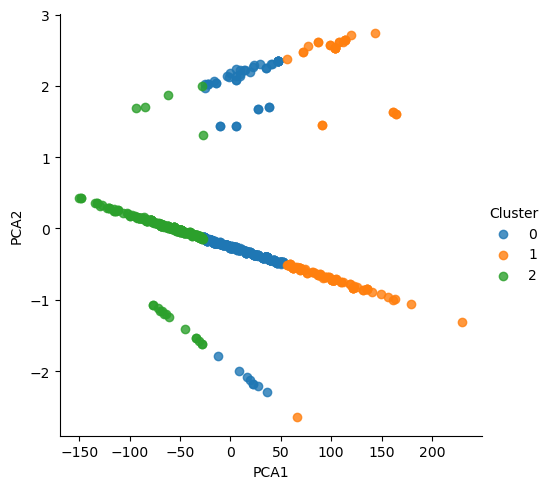

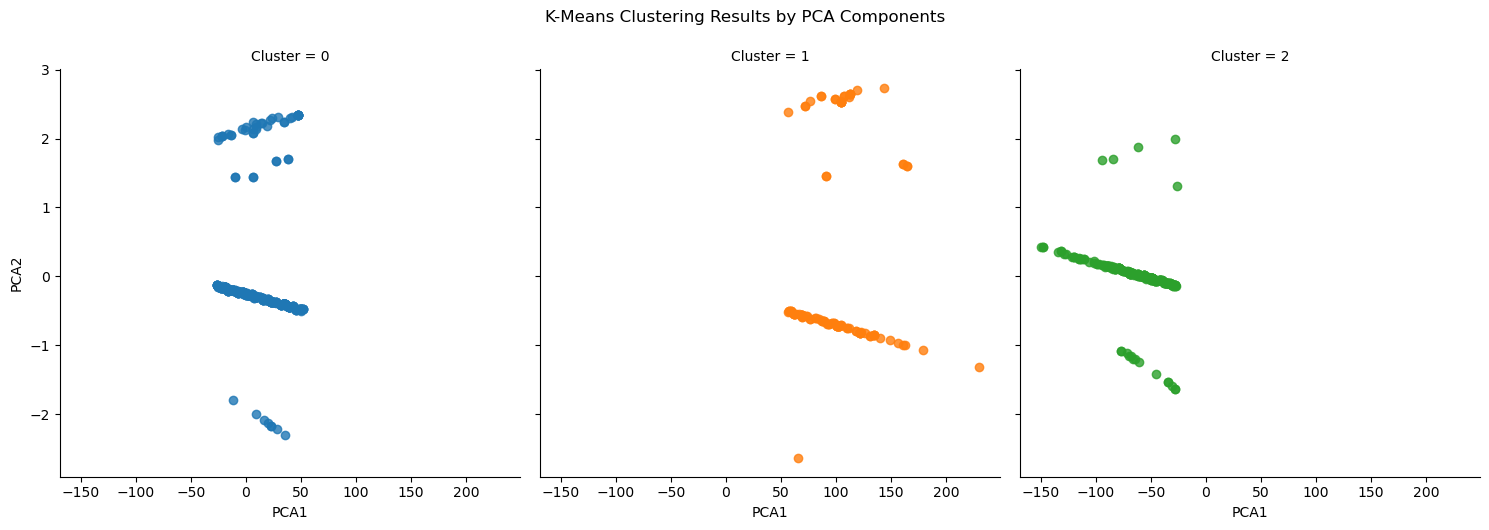

In [187]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

agg_df['PCA1'] = pca_result[:, 0]
agg_df['PCA2'] = pca_result[:, 1]

sns.lmplot(x='PCA1', y='PCA2', hue='Cluster', data=agg_df, fit_reg=False); 

sns.lmplot(x='PCA1', y='PCA2', data=agg_df, hue='Cluster', col='Cluster', fit_reg=False)
plt.suptitle("K-Means Clustering Results by PCA Components", y=1.05)
plt.show()

In [36]:
#Calculate and display the average fuel consumption and CO2 emission for each cluster to 
#interpret what each group represents
cluster_summary = agg_df.groupby('Cluster')[['avg_fuel_consumption','avg_co2_emission']].mean()
print(cluster_summary)

         avg_fuel_consumption  avg_co2_emission
Cluster                                        
0                   11.994894        269.136155
1                   16.337246        358.081522
2                    8.414220        194.488582


### 🔍 K-Means Clustering Summary
- **Clustering objective**: Group car makes/models based on the average fuel consumption and CO2 emmisions.
- **Data used**: Aggregared dataset
- **Features selected**:
  1. `avg_fuel_consumption`
  2. `avg_co2_emission`
- **Clustering method**: K-Means (unsupervised learning)
- Number of clusters: 3 (grouped similar car models based on their fuel usage and CO2 emissios)

#### 📌 Observations:
- Cluster columns were added to the dataset in a new column calles `Cluster`
- Each cluster shows distinct average emission and consumption patterns.
- Results based on average of each clusters:
  1. Cluster 2: most fuel-efficient and eco-friendly car models.
  2. Cluster 1: highest fuel consumption and emission.
  3. Cluster 0: average performers.
- Principal Component Analysis) was used to reduce 2-dimensional feature space into two principle components (`PCA1` and `PCA2`) to help visualize the clusters more clearly in scatter plot.

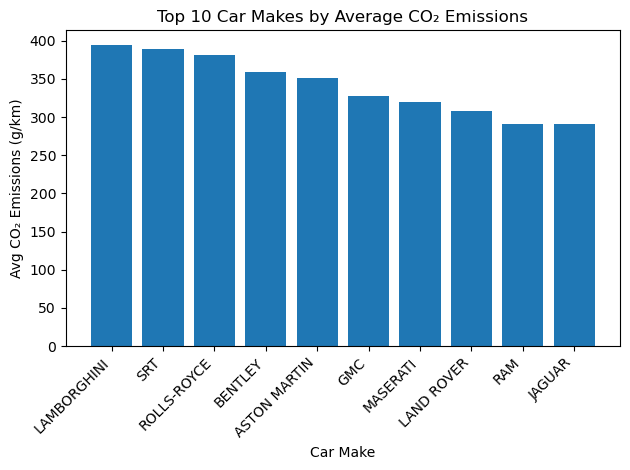

In [43]:
# 1) Bar chart: Top 10 makes by avg CO₂ emissions
avg_co2 = df.groupby('MAKE')['CO2EMISSIONS'].mean()
top10 = avg_co2.sort_values(ascending=False).head(10)

plt.figure()
# positions 0–9
x_pos = np.arange(len(top10))
plt.bar(x_pos, top10.values)
plt.xticks(x_pos, top10.index, rotation=45, ha='right')
plt.xlabel('Car Make')
plt.ylabel('Avg CO₂ Emissions (g/km)')
plt.title('Top 10 Car Makes by Average CO₂ Emissions')
plt.tight_layout()
plt.savefig('chart_bar_top10.png', dpi=300)
plt.show()

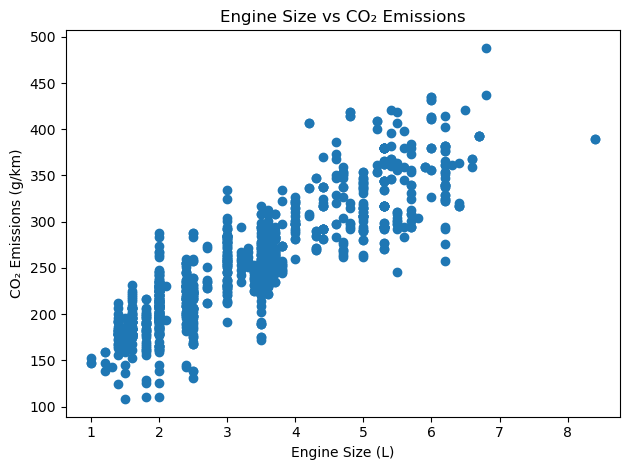

In [44]:
# 2) Scatter: Engine size vs CO₂
plt.figure()
plt.scatter(df['ENGINESIZE'], df['CO2EMISSIONS'])
plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.title('Engine Size vs CO₂ Emissions')
plt.tight_layout()
plt.savefig('chart_scatter_enginesize_co2.png', dpi=300)
plt.show()

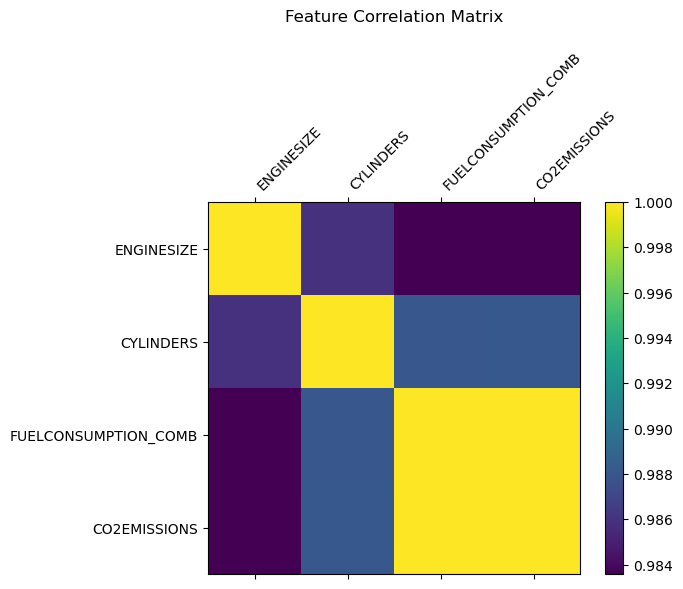

In [63]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*not compatible with tight_layout.*",
    category=UserWarning
)

# 3) Heatmap: Correlation of numeric features
nums = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
corr = nums.corr()

plt.figure()
# matshow puts color‐coded grid
plt.matshow(corr, fignum=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='left')
plt.yticks(range(len(corr)), corr.index)
plt.title('Feature Correlation Matrix', pad=20)
plt.colorbar()
plt.tight_layout()
plt.savefig('chart_heatmap_corr.png', dpi=300)
plt.show()



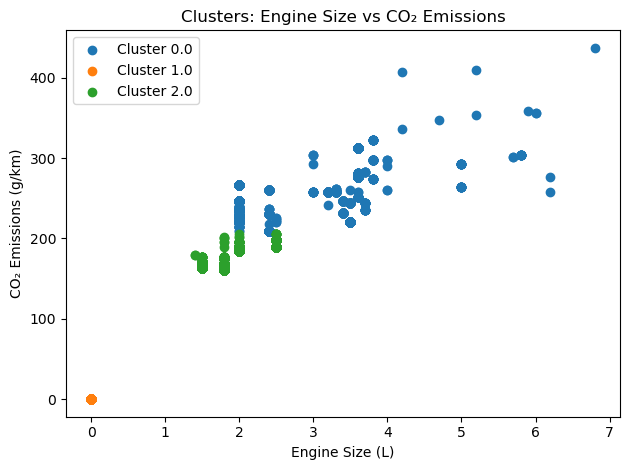

In [66]:
# 4) Cluster diagram: Engine size vs CO₂ colored by cluster

if 'cluster' in df:
    plt.figure()
    for cl in sorted(df['cluster'].unique()):
        mask = df['cluster']==cl
        plt.scatter(df.loc[mask,'ENGINESIZE'],
                    df.loc[mask,'CO2EMISSIONS'],
                    label=f'Cluster {cl}')
    plt.xlabel('Engine Size (L)')
    plt.ylabel('CO₂ Emissions (g/km)')
    plt.title('Clusters: Engine Size vs CO₂ Emissions')
    plt.legend()
    plt.tight_layout()
    plt.savefig('chart_clusters.png', dpi=300)
    plt.show()

## Visualization Summary

**Visualization objective:**  
Translate the cleaned data and ML results into clear, actionable charts.

**Data used:**  
– Row-level “Cleaned & Merged Dataset_Phase1” (per-vehicle records)  

---

### 1) Top 10 Car Makes by Average CO₂ Emissions  
- **What it shows:**  
  Which manufacturers have the highest carbon footprints on average.  
- **Why it matters:**  
  Highlights target brands for efficiency improvements or regulatory focus.

---

### 2) Engine Size vs CO₂ Emissions Scatter  
- **What it shows:**  
  Relationship between engine displacement (L) and CO₂ output (g/km).  
- **Why it matters:**  
  Confirms the positive trend—larger engines typically emit more CO₂, supporting downsizing strategies.

---

### 3) Feature Correlation Heatmap  
- **What it shows:**  
  Pairwise Pearson correlations among:  
  1. Engine size  
  2. Cylinder count  
  3. Combined fuel consumption  
  4. CO₂ emissions  
- **Why it matters:**  
  Quickly identifies which variables drive emissions most strongly, guiding feature selection for ML models.

### 4) Cluster Diagram  
- **What it shows:**  
  Per-vehicle engine size vs CO₂ emissions, colored by cluster (low/medium/high).  
- **Why it matters:**  
  Visual segmentation enables tailored interventions for each group rather than “one-size-fits-all.”  


---

## Key Insights

- **High-emitter brands** stand out clearly in the bar chart—these should be the priority for carbon-reduction measures.  
- **Engine displacement** is the dominant factor in emissions, as shown by the tight upward trend in the scatter plot.  
- **Fuel-consumption and CO₂** correlate almost perfectly, validating the use of either metric in subsequent ML tasks.  
- **Clustering** reveals three natural groups—eco-friendly, average, and high-emission vehicles—enabling targeted policies and product strategies.  
---


